# Step 7.5 — Compare SimPy vs PRoM Simulations (Same Validation Metrics)

This notebook compares three simulation sources using the **exact same 5 metrics** from Step 7 simulator validation:
1. `trace_length_dist_l1`
2. `top20_activity_rel_error_mean`
3. `transition_matrix_l1`
4. `duration_median_rel_error`
5. `loop_rel_error`

Sources compared:
- SimPy simulation (your current pipeline output)
- PRoM Inductive simulation
- PRoM Heuristic simulation

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# ─── Paths ────────────────────────────────────────────────────────────────────

OUTPUT_DIR = Path('./output')

# Real reference data
REAL_FEATURES_PARQUET = OUTPUT_DIR / 'case_step_features.parquet'
REAL_FEATURES_CSV = OUTPUT_DIR / 'case_step_features.csv'

# SimPy baseline
SIMPY_TRACE_PATH = OUTPUT_DIR / 'sim_trace_table.csv'
SIMPY_EPISODE_PATH = OUTPUT_DIR / 'sim_episode_summary.csv'

# PRoM exports
PROM_INDUCTIVE_TRACE_PATH = OUTPUT_DIR / 'prom_inductive_sim_trace_table.csv'
PROM_INDUCTIVE_EPISODE_PATH = OUTPUT_DIR / 'prom_inductive_sim_episode_summary.csv'
PROM_HEURISTIC_TRACE_PATH = OUTPUT_DIR / 'prom_heuristic_sim_trace_table.csv'
PROM_HEURISTIC_EPISODE_PATH = OUTPUT_DIR / 'prom_heuristic_sim_episode_summary.csv'

# Output artifacts
COMPARE_BY_RUN_PATH = OUTPUT_DIR / 'sim_validation_metrics_by_source_run.csv'
COMPARE_REPORT_PATH = OUTPUT_DIR / 'sim_validation_report_by_source.csv'
CHART_PATH = OUTPUT_DIR / 'sim_comparison_chart.png'

print('Output dir:', OUTPUT_DIR.resolve())

Output dir: /mnt/HDD/Code/Git/bureaucratic-workflow-analyzer/output


In [2]:
# ─── Load real reference data ─────────────────────────────────────────────────

if REAL_FEATURES_PARQUET.exists():
    real_df = pd.read_parquet(REAL_FEATURES_PARQUET)
    real_loaded_from = REAL_FEATURES_PARQUET
elif REAL_FEATURES_CSV.exists():
    real_df = pd.read_csv(REAL_FEATURES_CSV)
    real_loaded_from = REAL_FEATURES_CSV
else:
    raise FileNotFoundError(
        'Missing real features file. Expected case_step_features.parquet or '
        'case_step_features.csv in ./output'
    )

if 'timestamp' in real_df.columns:
    real_df['timestamp'] = pd.to_datetime(real_df['timestamp'], utc=True, errors='coerce')

print(f'Real rows: {len(real_df):,} (from {real_loaded_from.name})')

Real rows: 262,628 (from case_step_features.parquet)


In [3]:
# ─── Metric helpers ───────────────────────────────────────────────────────────

def build_real_case_summary(real_features: pd.DataFrame) -> pd.DataFrame:
    base = real_features.sort_values(['municipality', 'case_id', 'step_index'])

    case_steps = base.groupby(['municipality', 'case_id'])['step_index'].max().add(1).rename('steps')
    case_duration = (
        base.groupby(['municipality', 'case_id'])['time_since_case_start_hours']
        .max()
        .rename('duration_hours')
    )

    def loops_for_case(df_case: pd.DataFrame) -> int:
        counts = df_case['activity'].value_counts()
        return int((counts > 1).sum())

    case_loops = (
        base.groupby(['municipality', 'case_id'], group_keys=False)
        .apply(loops_for_case, include_groups=False)
        .rename('loops')
    )
    case_completed = (
        base.groupby(['municipality', 'case_id'])['case_completed'].max().rename('case_completed')
    )

    return pd.concat([case_steps, case_duration, case_loops, case_completed], axis=1).reset_index()


def build_sim_case_summary(
    sim_trace: pd.DataFrame, sim_episode: pd.DataFrame | None
) -> pd.DataFrame:
    needed_cols = {'municipality', 'case_id', 'steps', 'duration_hours', 'loops', 'case_completed'}

    if sim_episode is not None and needed_cols.issubset(sim_episode.columns):
        return sim_episode[
            ['municipality', 'case_id', 'steps', 'duration_hours', 'loops', 'case_completed']
        ].copy()

    base = sim_trace.sort_values(['municipality', 'case_id', 'step_index'])
    case_steps = base.groupby(['municipality', 'case_id'])['step_index'].max().add(1).rename('steps')

    if 'time_since_case_start_hours' in base.columns:
        case_duration = (
            base.groupby(['municipality', 'case_id'])['time_since_case_start_hours']
            .max()
            .rename('duration_hours')
        )
    elif 'timestamp' in base.columns:
        t0 = base.groupby(['municipality', 'case_id'])['timestamp'].min()
        t1 = base.groupby(['municipality', 'case_id'])['timestamp'].max()
        case_duration = ((t1 - t0).dt.total_seconds() / 3600.0).rename('duration_hours')
    else:
        raise ValueError(
            'Cannot infer duration_hours: provide time_since_case_start_hours or timestamp.'
        )

    def loops_for_case(df_case: pd.DataFrame) -> int:
        counts = df_case['activity'].value_counts()
        return int((counts > 1).sum())

    case_loops = (
        base.groupby(['municipality', 'case_id'], group_keys=False)
        .apply(loops_for_case, include_groups=False)
        .rename('loops')
    )

    if 'case_completed' in base.columns:
        case_completed = (
            base.groupby(['municipality', 'case_id'])['case_completed'].max().rename('case_completed')
        )
    else:
        case_completed = pd.Series(True, index=case_steps.index, name='case_completed')

    return pd.concat([case_steps, case_duration, case_loops, case_completed], axis=1).reset_index()


def relative_error(real_value: float, sim_value: float) -> float:
    denom = max(abs(float(real_value)), 1e-9)
    return abs(float(sim_value) - float(real_value)) / denom


def distribution_l1_distance(real_series: pd.Series, sim_series: pd.Series) -> float:
    r = real_series.value_counts(normalize=True)
    s = sim_series.value_counts(normalize=True)
    idx = sorted(set(r.index).union(set(s.index)))
    rv = np.array([float(r.get(i, 0.0)) for i in idx])
    sv = np.array([float(s.get(i, 0.0)) for i in idx])
    return float(np.abs(rv - sv).sum())


def normalized_transition_distance(real_trans: pd.Series, sim_trans: pd.Series) -> float:
    r = real_trans.value_counts(normalize=True)
    s = sim_trans.value_counts(normalize=True)
    idx = list(dict.fromkeys(list(r.index) + list(s.index)))
    rv = np.array([float(r.get(i, 0.0)) for i in idx])
    sv = np.array([float(s.get(i, 0.0)) for i in idx])
    return float(np.abs(rv - sv).sum())


def build_transition_series(df: pd.DataFrame) -> pd.Series:
    t = df[['activity', 'next_activity']].copy()
    t = t[t['next_activity'].notna()]
    t['activity'] = t['activity'].astype(str)
    t['next_activity'] = t['next_activity'].astype(str)
    t = t[~t['next_activity'].isin(['', 'nan', 'None'])]
    return pd.Series(list(zip(t['activity'], t['next_activity'])))

In [4]:
# ─── Loading & metrics ────────────────────────────────────────────────────────

def load_simulation_source(
    source_name: str, trace_path: Path, episode_path: Path
) -> tuple[pd.DataFrame, pd.DataFrame | None]:
    if not trace_path.exists():
        raise FileNotFoundError(f'[{source_name}] Missing trace file: {trace_path}')

    trace_df = pd.read_csv(trace_path)
    episode_df = pd.read_csv(episode_path) if episode_path.exists() else None

    if 'timestamp' in trace_df.columns:
        trace_df['timestamp'] = pd.to_datetime(trace_df['timestamp'], utc=True, errors='coerce')

    if 'run_id' not in trace_df.columns:
        trace_df['run_id'] = 1
    trace_df['run_id'] = pd.to_numeric(trace_df['run_id'], errors='coerce').fillna(1).astype(int)

    if episode_df is not None:
        if 'run_id' not in episode_df.columns:
            episode_df['run_id'] = 1
        episode_df['run_id'] = (
            pd.to_numeric(episode_df['run_id'], errors='coerce').fillna(1).astype(int)
        )

    ep_rows = 0 if episode_df is None else len(episode_df)
    print(f'[{source_name}] trace rows: {len(trace_df):,};  episode rows: {ep_rows:,}')
    return trace_df, episode_df


def compute_metrics_by_run(
    real_df: pd.DataFrame,
    trace_df: pd.DataFrame,
    episode_df: pd.DataFrame | None,
 ) -> pd.DataFrame:
    real_case_summary = build_real_case_summary(real_df)

    real_act = real_df['activity'].value_counts(normalize=True)
    top_acts = real_act.head(20).index.tolist()
    real_top20_mass = float(real_act.reindex(top_acts).fillna(0.0).sum())

    real_trans = build_transition_series(real_df)
    real_unique_edges = float(real_trans.nunique())

    real_trace_median_steps = float(real_case_summary['steps'].median())
    real_duration_median = float(real_case_summary['duration_hours'].median())
    real_loop_mean = float(real_case_summary['loops'].mean())

    if episode_df is None:
        run_ids = sorted(trace_df['run_id'].unique().tolist())
    else:
        run_ids = sorted(
            set(trace_df['run_id'].unique()).intersection(set(episode_df['run_id'].unique()))
        )

    if not run_ids:
        raise RuntimeError('No run_id found for evaluation.')

    rows = []
    for run_id in run_ids:
        trace_run = trace_df[trace_df['run_id'] == run_id].copy()
        episode_run = None if episode_df is None else episode_df[episode_df['run_id'] == run_id].copy()
        sim_case = build_sim_case_summary(trace_run, episode_run)

        trace_length_dist_l1 = distribution_l1_distance(real_case_summary['steps'], sim_case['steps'])

        sim_act = trace_run['activity'].value_counts(normalize=True)
        top_act_rel_errors = [
            relative_error(real_act[a], float(sim_act.get(a, 0.0))) for a in top_acts
        ]
        top_act_rel_error_mean = float(np.mean(top_act_rel_errors)) if top_act_rel_errors else np.nan

        sim_trans = build_transition_series(trace_run)
        transition_matrix_l1 = normalized_transition_distance(real_trans, sim_trans)

        sim_duration_median = float(sim_case['duration_hours'].median())
        duration_median_rel_error = relative_error(real_duration_median, sim_duration_median)

        sim_loop_mean = float(sim_case['loops'].mean())
        loop_rel_error = relative_error(real_loop_mean, sim_loop_mean)

        rows.append(
            {
                'run_id': int(run_id),
                'trace_length_dist_l1': trace_length_dist_l1,
                'top20_activity_rel_error_mean': top_act_rel_error_mean,
                'transition_matrix_l1': transition_matrix_l1,
                'duration_median_rel_error': duration_median_rel_error,
                'loop_rel_error': loop_rel_error,
                'sim_trace_median_steps': float(sim_case['steps'].median()),
                'sim_top20_mass': float(sim_act.reindex(top_acts).fillna(0.0).sum()),
                'sim_unique_edges': float(sim_trans.nunique()),
                'sim_duration_median': sim_duration_median,
                'sim_loop_mean': sim_loop_mean,
                'real_trace_median_steps': real_trace_median_steps,
                'real_top20_mass': real_top20_mass,
                'real_unique_edges': real_unique_edges,
                'real_duration_median': real_duration_median,
                'real_loop_mean': real_loop_mean,
            }
        )

    return pd.DataFrame(rows).sort_values('run_id').reset_index(drop=True)

In [5]:
# ─── Thresholds ───────────────────────────────────────────────────────────────

TRACE_L1_THRESHOLD = 0.60
TRANSITION_L1_THRESHOLD = 0.80
TOP_ACTIVITY_REL_THRESHOLD = 0.20
DURATION_REL_THRESHOLD = 0.25
LOOP_REL_THRESHOLD = 0.20

thresholds = {
    'trace_length_dist_l1': TRACE_L1_THRESHOLD,
    'top20_activity_rel_error_mean': TOP_ACTIVITY_REL_THRESHOLD,
    'transition_matrix_l1': TRANSITION_L1_THRESHOLD,
    'duration_median_rel_error': DURATION_REL_THRESHOLD,
    'loop_rel_error': LOOP_REL_THRESHOLD,
}


def build_source_report(source_name: str, metrics_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    n_runs = int(len(metrics_df))

    for metric_name, threshold in thresholds.items():
        vals = pd.to_numeric(metrics_df[metric_name], errors='coerce').dropna()
        mean_error = float(vals.mean()) if len(vals) else np.nan
        std_error = float(vals.std(ddof=1)) if len(vals) > 1 else 0.0
        ci95 = float(1.96 * std_error / np.sqrt(len(vals))) if len(vals) > 1 else 0.0

        pass_mask = vals < threshold
        pass_rate = float(pass_mask.mean()) if len(vals) else np.nan

        rows.append(
            {
                'source': source_name,
                'metric': metric_name,
                'n_runs': n_runs,
                'error_mean': mean_error,
                'error_std': std_error,
                'error_ci95_low': mean_error - ci95 if np.isfinite(mean_error) else np.nan,
                'error_ci95_high': mean_error + ci95 if np.isfinite(mean_error) else np.nan,
                'threshold': float(threshold),
                'pass_rate': pass_rate,
                'pass': bool(pass_rate >= 0.60),
            }
        )

    report = pd.DataFrame(rows)
    report['pass'] = report['pass'].astype(bool)
    return report

In [6]:
# ─── Run evaluation for all sources ──────────────────────────────────────────

sources = [
    ('simpy', SIMPY_TRACE_PATH, SIMPY_EPISODE_PATH),
    ('prom_inductive', PROM_INDUCTIVE_TRACE_PATH, PROM_INDUCTIVE_EPISODE_PATH),
    ('prom_heuristic', PROM_HEURISTIC_TRACE_PATH, PROM_HEURISTIC_EPISODE_PATH),
]

metrics_by_source_runs: list[pd.DataFrame] = []
report_rows: list[pd.DataFrame] = []

for source_name, trace_path, episode_path in sources:
    try:
        trace_df, episode_df = load_simulation_source(source_name, trace_path, episode_path)
    except FileNotFoundError as e:
        print(f'  SKIP {source_name}: {e}')
        continue

    by_run = compute_metrics_by_run(real_df, trace_df, episode_df)
    by_run.insert(0, 'source', source_name)
    metrics_by_source_runs.append(by_run)

    source_report = build_source_report(source_name, by_run)
    report_rows.append(source_report)

if not metrics_by_source_runs:
    raise RuntimeError('No sources could be evaluated. Check that output CSVs exist.')

metrics_by_source_runs_df = pd.concat(metrics_by_source_runs, ignore_index=True)
report_df = pd.concat(report_rows, ignore_index=True)

metrics_by_source_runs_df.to_csv(COMPARE_BY_RUN_PATH, index=False)
report_df.to_csv(COMPARE_REPORT_PATH, index=False)

print('Saved by-run comparison:', COMPARE_BY_RUN_PATH.resolve())
print('Saved summary report   :', COMPARE_REPORT_PATH.resolve())

[simpy] trace rows: 483,247;  episode rows: 12,000
[prom_inductive] trace rows: 179,003;  episode rows: 4,993
[prom_heuristic] trace rows: 28,073;  episode rows: 5,000
Saved by-run comparison: /mnt/HDD/Code/Git/bureaucratic-workflow-analyzer/output/sim_validation_metrics_by_source_run.csv
Saved summary report   : /mnt/HDD/Code/Git/bureaucratic-workflow-analyzer/output/sim_validation_report_by_source.csv


## How to read this comparison

This section compares how close each simulator is to the **real process logs**.

- Each metric is an error: **lower is better** (0 means perfect match).
- In each metric panel, the **best performer** (lowest error) is highlighted in green.
- Dashed threshold lines are shown in every panel.
- Each bar is labeled **PASS**/**FAIL** against its panel threshold.
- In the last panel, pass-rate uses target $\ge 60\%$ and also shows PASS/FAIL per source.

In short:
- Use the table first to inspect exact values and pass/fail.
- Use the charts to quickly spot each simulator's strongest metrics and threshold compliance.


VALIDATION REPORT
                       metric         source  error_mean  error_std  threshold  pass_rate      status
    duration_median_rel_error prom_heuristic      1.0000     0.0000       0.25       0.00 TODO (FAIL)
    duration_median_rel_error prom_inductive      0.9909     0.0000       0.25       0.00 TODO (FAIL)
    duration_median_rel_error          simpy      0.0696     0.0244       0.25       1.00 DONE (PASS)
               loop_rel_error prom_heuristic      0.8723     0.0000       0.20       0.00 TODO (FAIL)
               loop_rel_error prom_inductive      0.9079     0.0000       0.20       0.00 TODO (FAIL)
               loop_rel_error          simpy      1.0641     0.0391       0.20       0.00 TODO (FAIL)
top20_activity_rel_error_mean prom_heuristic      0.4500     0.0000       0.20       0.00 TODO (FAIL)
top20_activity_rel_error_mean prom_inductive      0.7943     0.0000       0.20       0.00 TODO (FAIL)
top20_activity_rel_error_mean          simpy      0.0941     0.

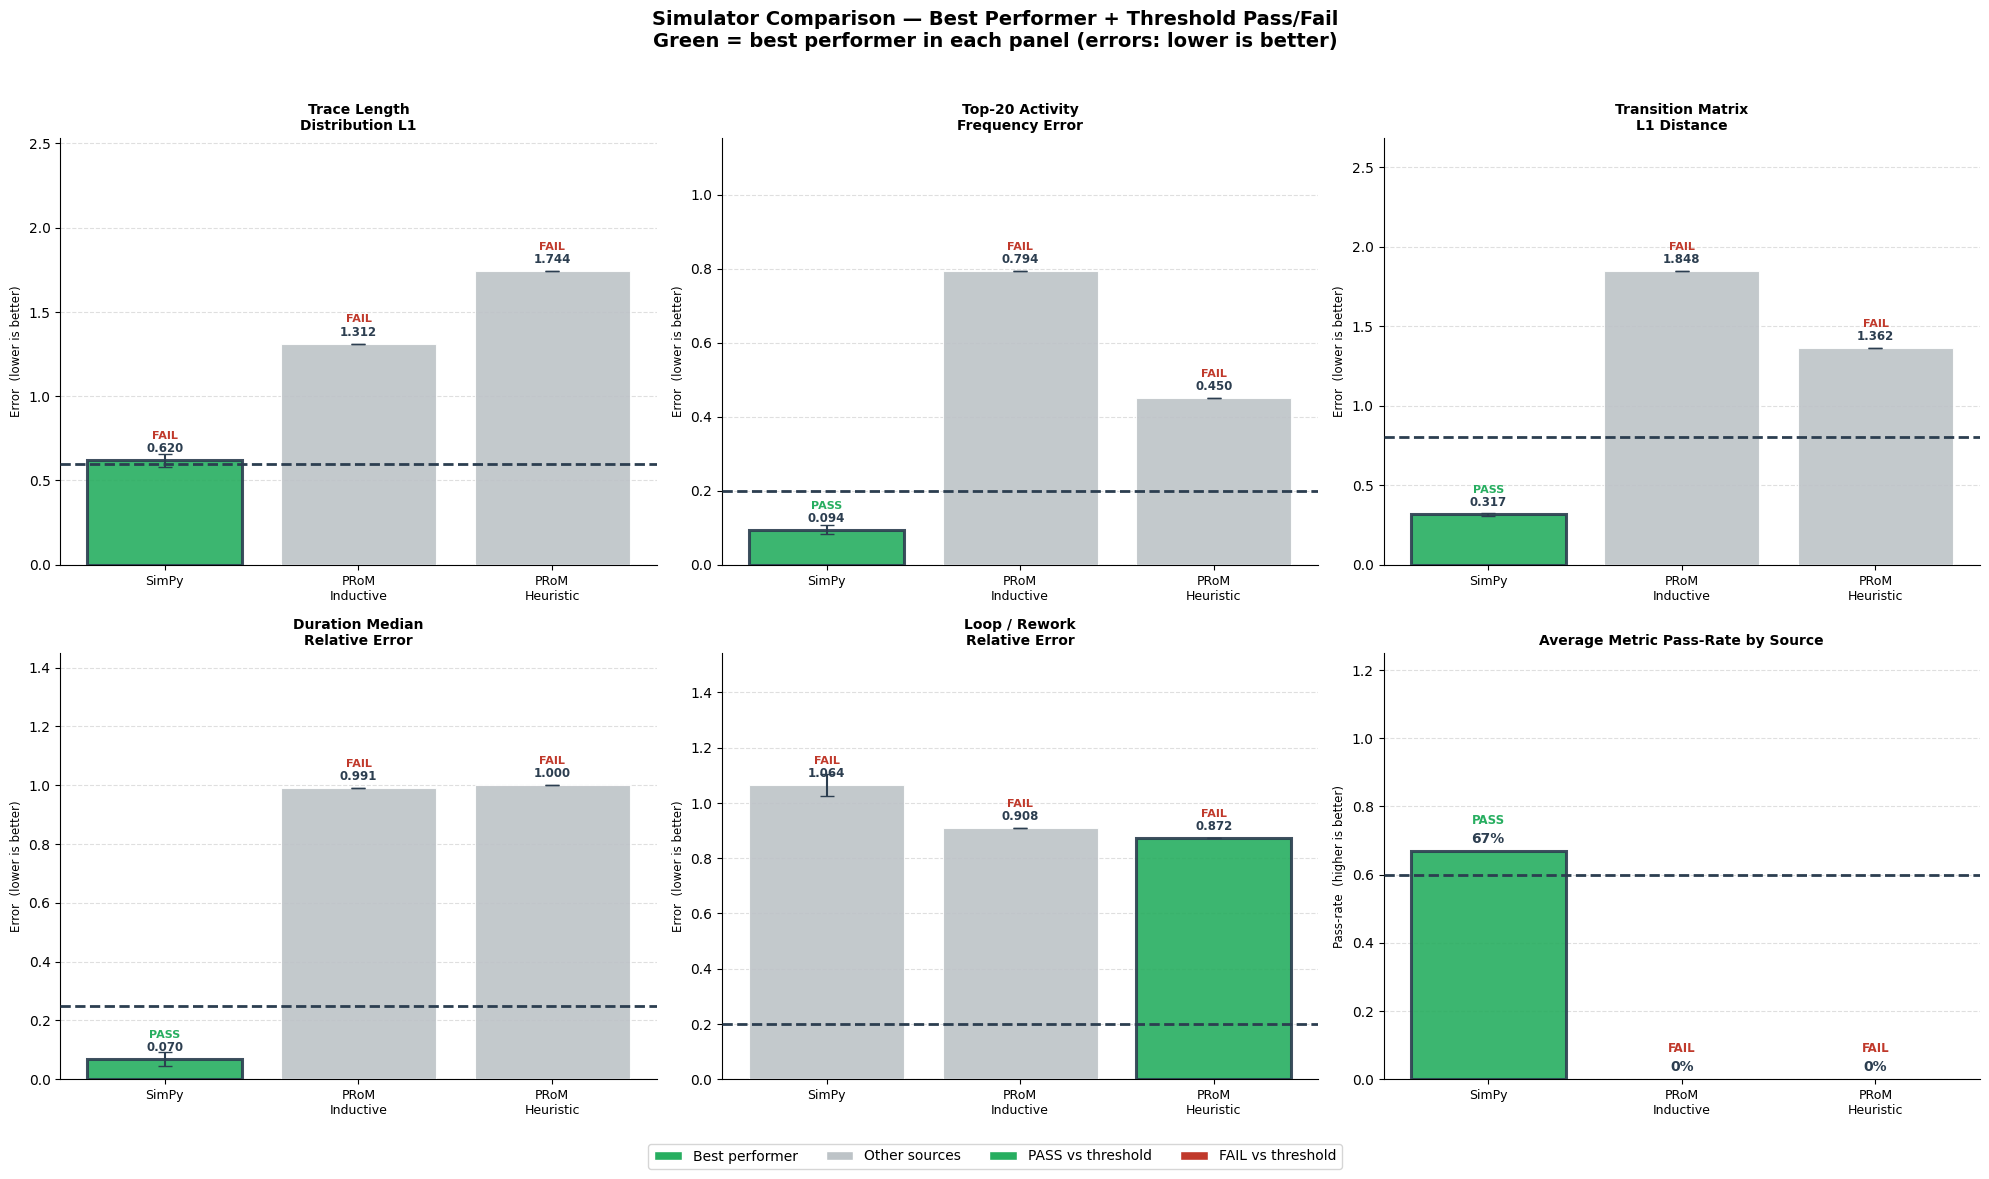

In [10]:
# ─── Pretty summary table ─────────────────────────────────────────────────────

metric_descriptions = {
    'trace_length_dist_l1': 'Difference in case step-count distribution (lower = closer).',
    'top20_activity_rel_error_mean': 'Avg relative error on top-20 activity frequencies.',
    'transition_matrix_l1': 'Difference in transition probability matrix (activity→next).',
    'duration_median_rel_error': 'Relative error of median case duration.',
    'loop_rel_error': 'Relative error of average loop/rework level.',
}

table_df = (
    report_df[['source', 'metric', 'error_mean', 'error_std', 'threshold', 'pass_rate', 'pass']]
    .copy()
    .sort_values(['metric', 'source'])
    .reset_index(drop=True)
)
table_df['description'] = table_df['metric'].map(metric_descriptions)
table_df['status'] = table_df['pass'].map({True: 'DONE (PASS)', False: 'TODO (FAIL)'})

for c in ['error_mean', 'error_std', 'threshold', 'pass_rate']:
    table_df[c] = pd.to_numeric(table_df[c], errors='coerce').round(4)

print('\n' + '=' * 100)
print('VALIDATION REPORT')
print('=' * 100)
print(
    table_df[['metric', 'source', 'error_mean', 'error_std', 'threshold', 'pass_rate', 'status']]
    .to_string(index=False)
)

best_by_metric = (
    table_df.sort_values(['metric', 'error_mean'])
    .groupby('metric', as_index=False)
    .first()[['metric', 'source', 'error_mean']]
    .rename(columns={'source': 'best_source', 'error_mean': 'best_error_mean'})
)
print('\n--- Best source per metric ---')
print(best_by_metric.to_string(index=False))


# ─── Charts ───────────────────────────────────────────────────────────────────

metrics_order = [
    'trace_length_dist_l1',
    'top20_activity_rel_error_mean',
    'transition_matrix_l1',
    'duration_median_rel_error',
    'loop_rel_error',
]

metric_labels = {
    'trace_length_dist_l1': 'Trace Length\nDistribution L1',
    'top20_activity_rel_error_mean': 'Top-20 Activity\nFrequency Error',
    'transition_matrix_l1': 'Transition Matrix\nL1 Distance',
    'duration_median_rel_error': 'Duration Median\nRelative Error',
    'loop_rel_error': 'Loop / Rework\nRelative Error',
}

SOURCE_ORDER = ['simpy', 'prom_inductive', 'prom_heuristic']
SOURCE_LABELS = {
    'simpy': 'SimPy',
    'prom_inductive': 'PRoM\nInductive',
    'prom_heuristic': 'PRoM\nHeuristic',
}

# Best = green, Others = neutral
BEST_COLOR = PASS_COLOR
OTHER_COLOR = '#bdc3c7'
TEXT_COLOR = '#2c3e50'

available_sources = report_df['source'].unique().tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.ravel()
fig.suptitle(
    'Simulator Comparison — Best Performer + Threshold Pass/Fail\n'
    'Green = best performer in each panel (errors: lower is better)',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)

plot_df = report_df.copy()

for idx, metric_name in enumerate(metrics_order):
    ax = axes[idx]

    sub = (
        plot_df[plot_df['metric'] == metric_name]
        .set_index('source')
        .reindex([s for s in SOURCE_ORDER if s in available_sources])
        .reset_index()
        .dropna(subset=['error_mean'])
    )

    if sub.empty:
        ax.set_title(metric_labels.get(metric_name, metric_name) + '\n(no data)')
        ax.axis('off')
        continue

    threshold = float(sub['threshold'].iloc[0])
    x = np.arange(len(sub))
    error_vals = sub['error_mean'].values
    pass_flags = error_vals < threshold
    best_idx = int(np.argmin(error_vals))

    bar_colors = [BEST_COLOR if i == best_idx else OTHER_COLOR for i in range(len(sub))]
    edge_widths = [2.2 if i == best_idx else 0.8 for i in range(len(sub))]

    bars = ax.bar(
        x, error_vals,
        color=bar_colors, alpha=0.9,
        edgecolor='white', linewidth=0.8, zorder=3,
    )
    for i, bar in enumerate(bars):
        bar.set_linewidth(edge_widths[i])
        if i == best_idx:
            bar.set_edgecolor(TEXT_COLOR)

    yerr = sub['error_std'].fillna(0.0).values
    if yerr.sum() > 0:
        ax.errorbar(
            x, error_vals, yerr=yerr,
            fmt='none', ecolor=TEXT_COLOR, capsize=5, linewidth=1.5, zorder=4,
        )

    ax.axhline(
        threshold, color=THRESHOLD_COLOR, linestyle='--', linewidth=2.0, zorder=5,
    )

    max_val = float(np.nanmax(error_vals)) if len(error_vals) else 0.0
    y_ceil = max(max_val, threshold) * 1.45
    y_ceil = max(y_ceil, 0.05)
    ax.set_ylim(bottom=0, top=y_ceil)

    for bar, val, is_pass in zip(bars, error_vals, pass_flags):
        status_text = 'PASS' if bool(is_pass) else 'FAIL'
        status_color = PASS_COLOR if bool(is_pass) else FAIL_COLOR
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_ceil * 0.012,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8.5,
            color=TEXT_COLOR, fontweight='bold',
        )
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_ceil * 0.045,
            status_text,
            ha='center', va='bottom', fontsize=8,
            color=status_color, fontweight='bold',
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [SOURCE_LABELS.get(s, s) for s in sub['source'].tolist()],
        fontsize=9,
    )
    ax.set_title(metric_labels.get(metric_name, metric_name), fontsize=10, fontweight='semibold')
    ax.set_ylabel('Error  (lower is better)', fontsize=8.5)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

# ─── Panel 6: average pass-rate by source ─────────────────────────────────────
ax = axes[5]
pass_rate_df = (
    plot_df.groupby('source', as_index=False)['pass_rate'].mean()
    .set_index('source')
    .reindex([s for s in SOURCE_ORDER if s in available_sources])
    .reset_index()
    .dropna(subset=['pass_rate'])
)

PASS_THRESHOLD = 0.60

if not pass_rate_df.empty:
    x = np.arange(len(pass_rate_df))
    pass_vals = pass_rate_df['pass_rate'].values
    pass_flags = pass_vals >= PASS_THRESHOLD
    best_idx = int(np.argmax(pass_vals))

    pr_colors = [BEST_COLOR if i == best_idx else OTHER_COLOR for i in range(len(pass_rate_df))]
    edge_widths = [2.2 if i == best_idx else 0.8 for i in range(len(pass_rate_df))]

    bars = ax.bar(
        x, pass_vals,
        color=pr_colors, alpha=0.9,
        edgecolor='white', linewidth=0.8, zorder=3,
    )
    for i, bar in enumerate(bars):
        bar.set_linewidth(edge_widths[i])
        if i == best_idx:
            bar.set_edgecolor(TEXT_COLOR)

    ax.axhline(
        PASS_THRESHOLD, color=THRESHOLD_COLOR, linestyle='--', linewidth=2.0, zorder=5,
    )

    for bar, val, is_pass in zip(bars, pass_vals, pass_flags):
        status_text = 'PASS' if bool(is_pass) else 'FAIL'
        status_color = PASS_COLOR if bool(is_pass) else FAIL_COLOR
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f'{val:.0%}',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            color=TEXT_COLOR,
        )
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.07,
            status_text,
            ha='center', va='bottom', fontsize=8.5, fontweight='bold',
            color=status_color,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [SOURCE_LABELS.get(s, s) for s in pass_rate_df['source'].tolist()],
        fontsize=9,
    )
    ax.set_ylim(0, 1.25)
    ax.set_title('Average Metric Pass-Rate by Source', fontsize=10, fontweight='semibold')
    ax.set_ylabel('Pass-rate  (higher is better)', fontsize=8.5)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
else:
    axes[5].axis('off')

legend_handles = [
    Patch(facecolor=BEST_COLOR, edgecolor='white', label='Best performer'),
    Patch(facecolor=OTHER_COLOR, edgecolor='white', label='Other sources'),
    Patch(facecolor=PASS_COLOR, edgecolor='white', label='PASS vs threshold'),
    Patch(facecolor=FAIL_COLOR, edgecolor='white', label='FAIL vs threshold'),
]
fig.legend(
    handles=legend_handles,
    loc='lower center', ncol=4,
    fontsize=10, frameon=True,
    bbox_to_anchor=(0.5, -0.04),
)

plt.tight_layout()
plt.show()

## Analysis notes

### SimPy (custom simulator)

- ✅ Top-20 activity frequency, transition matrix, and duration are within threshold, indicating good fidelity for activity patterns and timing.
- ❌ Trace-length distribution L1 can sit slightly above threshold (~0.62 vs 0.60), so case lengths may be a bit more spread out than in real data.
- ❌ Loop/rework error can be high (~1.06), suggesting under-representation of repeated activities within a case.

### PRoM Inductive / Heuristic — common failure reasons

1. Duration error near 1.0: `play_out()` from process-model simulation tends to generate synthetic timestamps (epoch-anchored), so real durations are not reproduced by default.
2. High activity/transition error: discovered models encode reachable behavior, not empirical frequency calibration; rare paths can become over-represented.
3. High trace-length error: the discovered model often allows many more trace shapes than observed in real logs.

### Hyperparameter suggestions for PRoM

- Try increasing `noise_threshold` (e.g., 0.15–0.20) to simplify the model and bias toward common paths (trade-off: reduced coverage).
- Treat duration separately unless you inject realistic inter-event times post-simulation.
- If loop realism is critical, consider stochastic Petri net calibration or post-simulation loop constraints.